In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [3]:
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target 

In [4]:
print("✅ Data loaded!")
print(f"Shape: {df.shape}")

✅ Data loaded!
Shape: (20640, 9)


In [5]:
#  Question: What does our data actually look like?
print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== COLUMN NAMES & TYPES ===")
print(df.info())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

=== FIRST 5 ROWS ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

=== COLUMN NAMES & TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   P

In [6]:
# Question: Is our data clean or messy?
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n=== PRICE RANGE ===")
print(f"Cheapest house: ${df['Price'].min() * 100000:,.0f}")
print(f"Most expensive: ${df['Price'].max() * 100000:,.0f}")
print(f"Average price:  ${df['Price'].mean() * 100000:,.0f}")

=== MISSING VALUES ===
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates: 0

=== PRICE RANGE ===
Cheapest house: $14,999
Most expensive: $500,001
Average price:  $206,856


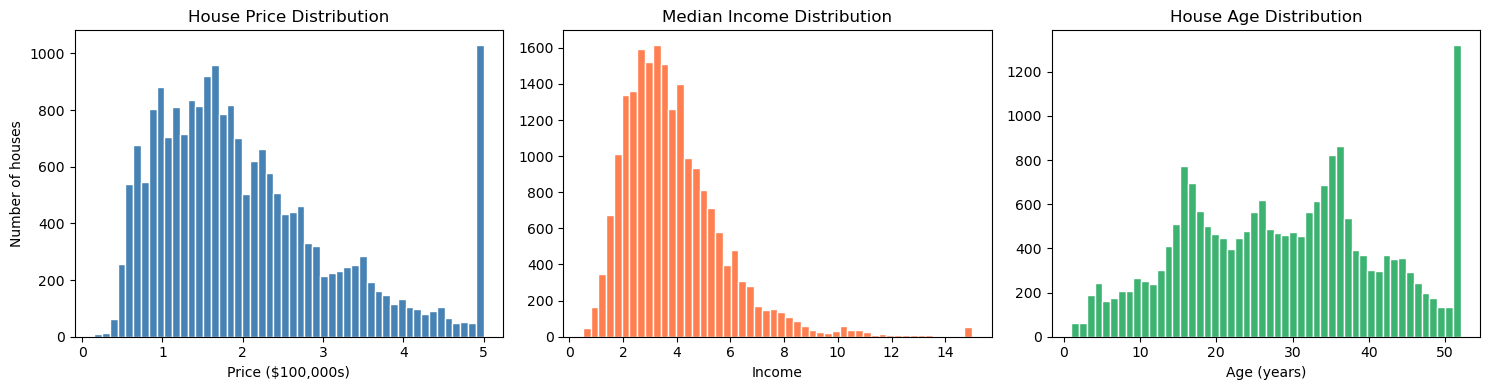

In [7]:
# Question: What does the price distribution look like?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Price distribution
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price ($100,000s)')
axes[0].set_ylabel('Number of houses')

# Chart 2: Income distribution
axes[1].hist(df['MedInc'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Median Income Distribution')
axes[1].set_xlabel('Income')

# Chart 3: House age distribution
axes[2].hist(df['HouseAge'], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('House Age Distribution')
axes[2].set_xlabel('Age (years)')

plt.tight_layout()
plt.show()

In [8]:
# Question: Which factors actually affect price the most?
# 1.0 = perfect positive, -1.0 = perfect negative, 0 = no relationship
correlation = df.corr()['Price'].sort_values(ascending=False)

print("=== CORRELATION WITH PRICE ===")
for col, val in correlation.items():
    bar = "█" * int(abs(val) * 20)
    direction = "↑" if val > 0 else "↓"
    print(f"{col:<15} {direction} {bar:<20} {val:.3f}")

=== CORRELATION WITH PRICE ===
Price           ↑ ████████████████████ 1.000
MedInc          ↑ █████████████        0.688
AveRooms        ↑ ███                  0.152
HouseAge        ↑ ██                   0.106
AveOccup        ↓                      -0.024
Population      ↓                      -0.025
Longitude       ↓                      -0.046
AveBedrms       ↓                      -0.047
Latitude        ↓ ██                   -0.144


C:\Users\Dispatch\AppData\Local\Temp\ipykernel_20928\741395867.py:19: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


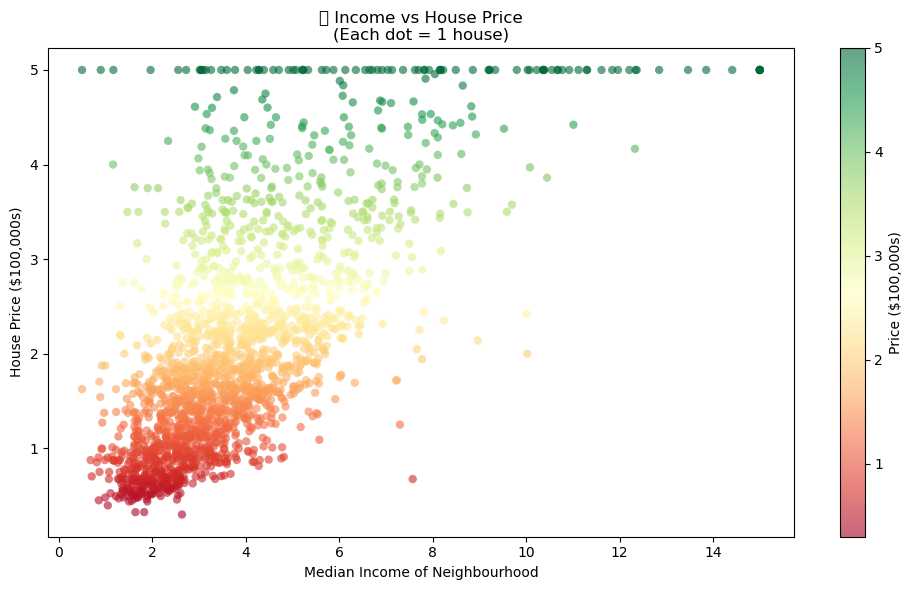

Correlation: 0.688
The richer the neighbourhood → the more expensive the house


In [10]:
# Question: Show me income vs price — is it really that strong?
plt.figure(figsize=(10, 6))

# Sample 2000 points so it doesn't get too crowded
sample = df.sample(2000, random_state=42)

scatter = plt.scatter(
    sample['MedInc'],
    sample['Price'],
    c=sample['Price'],        # color by price
    cmap='RdYlGn',            # red=cheap, green=expensive
    alpha=0.6,
    edgecolors='none'
)

plt.colorbar(scatter, label='Price ($100,000s)')
plt.xlabel('Median Income of Neighbourhood')
plt.ylabel('House Price ($100,000s)')
plt.title('💰 Income vs House Price\n(Each dot = 1 house)')
plt.tight_layout()
plt.show()

print(f"Correlation: {df['MedInc'].corr(df['Price']):.3f}")
print("The richer the neighbourhood → the more expensive the house")

C:\Users\Dispatch\AppData\Local\Temp\ipykernel_20928\3620375062.py:17: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dispatch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


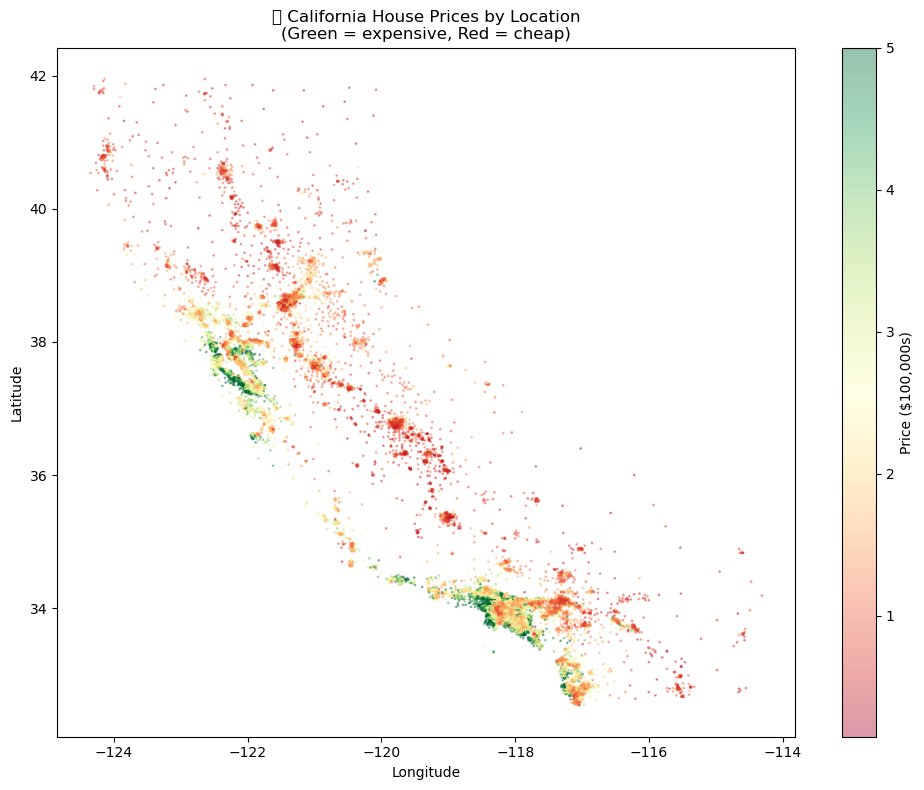

In [11]:
# Question: Does location in California affect price?
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Price'],
    cmap='RdYlGn',
    alpha=0.4,
    s=1                       # tiny dots so we can see the map shape
)

plt.colorbar(scatter, label='Price ($100,000s)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('🗺️ California House Prices by Location\n(Green = expensive, Red = cheap)')
plt.tight_layout()
plt.show()

In [12]:
# Question: How do we get this data ready for a model?
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (inputs) from target (what we predict)
X = df.drop('Price', axis=1)   # everything except price
y = df['Price']                 # just the price

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — brings all columns to same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # IMPORTANT: only transform, don't fit

print(f"Training houses: {len(X_train)}")
print(f"Testing houses:  {len(X_test)}")
print(f"\nBefore scaling — MedInc range: {X_train['MedInc'].min():.1f} to {X_train['MedInc'].max():.1f}")
print(f"After scaling  — MedInc range: {X_train_scaled[:,0].min():.1f} to {X_train_scaled[:,0].max():.1f}")

Training houses: 16512
Testing houses:  4128

Before scaling — MedInc range: 0.5 to 15.0
After scaling  — MedInc range: -1.8 to 5.8


In [13]:
# Question: How accurate is a simple linear regression?
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate
r2  = r2_score(y_test, lr_predictions)
mae = mean_absolute_error(y_test, lr_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("=== LINEAR REGRESSION RESULTS ===")
print(f"R² Score : {r2:.3f}  (1.0 = perfect, 0 = useless)")
print(f"MAE      : ${mae * 100000:,.0f}  (average prediction error)")
print(f"RMSE     : ${rmse * 100000:,.0f}  (punishes big errors more)")
print(f"\nOn average, our predictions are off by ${mae * 100000:,.0f}")

=== LINEAR REGRESSION RESULTS ===
R² Score : 0.576  (1.0 = perfect, 0 = useless)
MAE      : $53,320  (average prediction error)
RMSE     : $74,558  (punishes big errors more)

On average, our predictions are off by $53,320


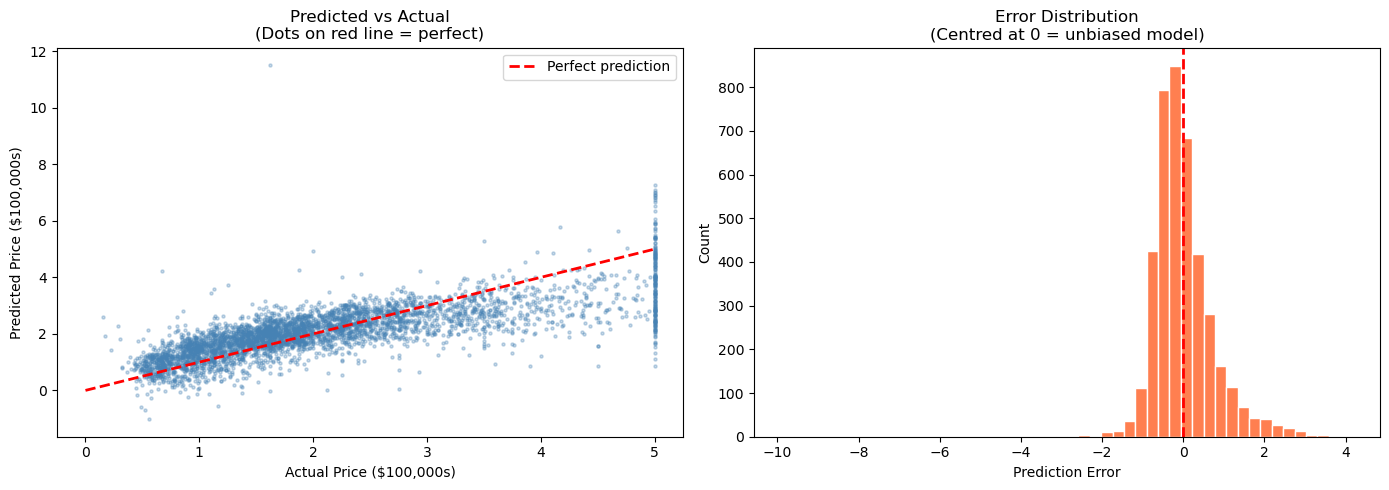

In [14]:
# Question: WHERE is our model going wrong?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Predicted vs Actual
axes[0].scatter(y_test, lr_predictions, alpha=0.3, color='steelblue', s=5)
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100,000s)')
axes[0].set_ylabel('Predicted Price ($100,000s)')
axes[0].set_title('Predicted vs Actual\n(Dots on red line = perfect)')
axes[0].legend()

# Chart 2: Error distribution
errors = y_test - lr_predictions
axes[1].hist(errors, bins=50, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution\n(Centred at 0 = unbiased model)')

plt.tight_layout()
plt.show()

In [16]:
# Question: Can a smarter model do better?
from sklearn.ensemble import RandomForestRegressor

# Random forest = hundreds of decision trees voting together
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    random_state=42,
    n_jobs=-1            # use all CPU cores — faster
)

rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

rf_r2   = r2_score(y_test, rf_predictions)
rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("=== RANDOM FOREST RESULTS ===")
print(f"R² Score : {rf_r2:.3f}")
print(f"MAE      : ${rf_mae * 100000:,.0f}")
print(f"RMSE     : ${rf_rmse * 100000:,.0f}")

print("\n=== COMPARISON ===")
print(f"{'Model':<20} {'R²':<10} {'MAE':<15}")
print(f"{'Linear Regression':<20} {r2:<10.3f} ${mae*100000:,.0f}")
print(f"{'Random Forest':<20} {rf_r2:<10.3f} ${rf_mae*100000:,.0f}")
print(f"\nImprovement: ${(mae - rf_mae) * 100000:,.0f} less error per prediction!")

=== RANDOM FOREST RESULTS ===
R² Score : 0.805
MAE      : $32,743
RMSE     : $50,514

=== COMPARISON ===
Model                R²         MAE            
Linear Regression    0.576      $53,320
Random Forest        0.805      $32,743

Improvement: $20,577 less error per prediction!


C:\Users\Dispatch\AppData\Local\Temp\ipykernel_20928\293251491.py:22: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dispatch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


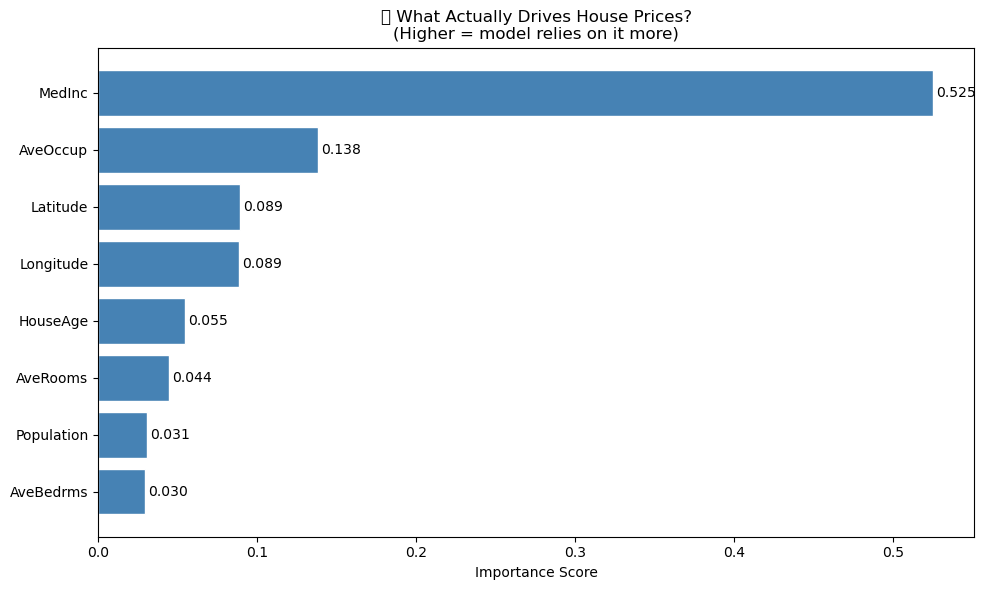

In [17]:
# Question: Which features does the model rely on most?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='steelblue',
    edgecolor='white'
)

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.xlabel('Importance Score')
plt.title('🔍 What Actually Drives House Prices?\n(Higher = model relies on it more)')
plt.tight_layout()
plt.show()

In [18]:
# Question: What if we push accuracy even further?
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
gb_predictions = gb_model.predict(X_test_scaled)

gb_r2   = r2_score(y_test, gb_predictions)
gb_mae  = mean_absolute_error(y_test, gb_predictions)

print("=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<25} {'R² Score':<12} {'Avg Error':<15} {'Winner?'}")
print("─" * 65)
print(f"{'Linear Regression':<25} {r2:<12.3f} ${mae*100000:>10,.0f}    {'⭐' if r2 == max(r2, rf_r2, gb_r2) else ''}")
print(f"{'Random Forest':<25} {rf_r2:<12.3f} ${rf_mae*100000:>10,.0f}    {'⭐' if rf_r2 == max(r2, rf_r2, gb_r2) else ''}")
print(f"{'Gradient Boosting':<25} {gb_r2:<12.3f} ${gb_mae*100000:>10,.0f}    {'⭐' if gb_r2 == max(r2, rf_r2, gb_r2) else ''}")

=== FINAL MODEL COMPARISON ===
Model                     R² Score     Avg Error       Winner?
─────────────────────────────────────────────────────────────────
Linear Regression         0.576        $    53,320    
Random Forest             0.805        $    32,743    
Gradient Boosting         0.819        $    32,747    ⭐


In [19]:
# Question: What would MY house be worth?
def predict_house_price(
    med_income,       # neighbourhood median income (1-15 scale)
    house_age,        # age in years
    avg_rooms,        # average rooms per house in area
    avg_bedrooms,     # average bedrooms
    population,       # neighbourhood population
    avg_occupancy,    # average people per household
    latitude,         # California latitude (32-42)
    longitude         # California longitude (-124 to -114)
):
    house = pd.DataFrame([[
        med_income, house_age, avg_rooms, avg_bedrooms,
        population, avg_occupancy, latitude, longitude
    ]], columns=X.columns)

    house_scaled = scaler.transform(house)
    price = rf_model.predict(house_scaled)[0]

    print(f"🏠 Estimated House Price: ${price * 100000:,.0f}")
    print(f"   (Model confidence R²: {rf_r2:.1%})")
    return price

# Example: typical San Francisco house
predict_house_price(
    med_income=8.0,
    house_age=30,
    avg_rooms=5.0,
    avg_bedrooms=1.0,
    population=800,
    avg_occupancy=2.5,
    latitude=37.77,
    longitude=-122.41
)

🏠 Estimated House Price: $434,113
   (Model confidence R²: 80.5%)


np.float64(4.341133599999996)